<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Mastering_Bar_Charts_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering Bar Charts: Visualizing Categorical Data in R**

### নোটবুক পরিচিতি (Metadata)
- Aim: আর (R) এবং ggplot2 ব্যবহার করে ক্যাটাগরিক্যাল ডেটার (যেমন: লিঙ্গ, প্রজাতি) ফ্রিকোয়েন্সি বা সংখ্যা কীভাবে প্রফেশনাল বার চার্টের মাধ্যমে ফুটিয়ে তোলা যায় তা শেখা।
- Dataset: starwars (tidyverse-এর বিল্ট-ইন ডাটাসেট)।
- Key Skills: ডেটা ক্লিনিং (Handling NAs), ফন্ট কাস্টমাইজেশন, বার সর্টিং (Sorting), এবং চার্ট ফ্লিপিং (Flipping)।

### কেন বার চার্ট ব্যবহার করবেন?
- ১. বিভিন্ন ক্যাটাগরির মধ্যে তুলনা করতে।
- ২. ডেটাসেটে কোন ক্যাটাগরি কতবার আছে (Count) তা দেখতে।
- ৩. র‍্যাঙ্কিং বা সর্টিং দেখানোর জন্য।

### ১. এনভায়রনমেন্ট ও ফন্ট সেটআপ
গ্রাফের সৌন্দর্য বাড়াতে আমরা গুগল ফন্ট "Poppins" ব্যবহার করছি।

In [6]:
install.packages('showtext')
install.packages('sysfonts')

library(tidyverse)
library(showtext)
library(sysfonts)

# গুগল ফন্ট যোগ করা
font_add_google("Poppins", "poppins")
showtext_auto()

# ডিফল্ট থিম হিসেবে Poppins সেট করা
theme_set(theme_test(base_size = 15) +
            theme(text = element_text(family = "poppins")))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### ২. বেসিক বার চার্ট (The Raw Start)
শুরুতে আমরা দেখব স্টার ওয়ার্স মুভির চরিত্রগুলোর মধ্যে লিঙ্গভেদে (Sex) সংখ্যা কেমন।

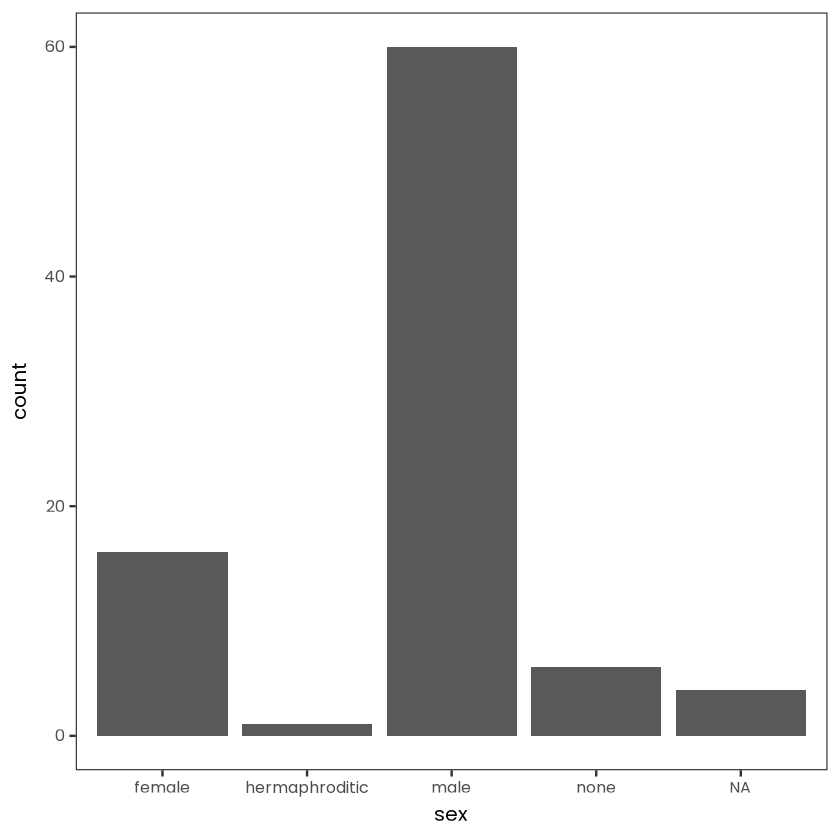

In [7]:
# প্রথম ধাপ: শুধু বার চার্ট তৈরি
starwars %>%
  ggplot(aes(x = sex)) +
  geom_bar()

__ব্যাখ্যা:__ geom_bar() স্বয়ংক্রিয়ভাবে প্রতিটি ক্যাটাগরির সংখ্যা (count) গণনা করে। লক্ষ্য করুন, এখানে 'NA' (তথ্য নেই এমন) একটি বারও দেখা যাচ্ছে।

### ৩. কালার ও লেবেল কাস্টমাইজেশন (Styling)
গ্রাফকে আরও আকর্ষণীয় করতে রঙ এবং শিরোনাম যোগ করা যাক।

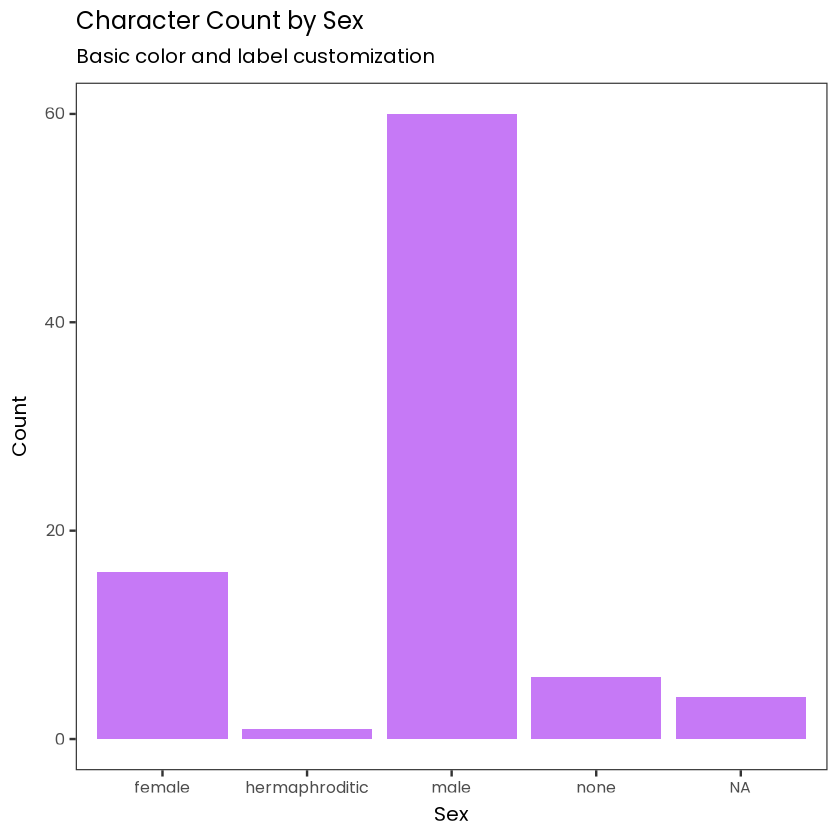

In [8]:
starwars %>%
  ggplot(aes(sex)) +
  geom_bar(fill = "purple", alpha = 0.6) +
  labs(title = "Character Count by Sex",
       subtitle = "Basic color and label customization",
       x = "Sex",
       y = "Count")

### ৪. ডেটা ক্লিনিং: drop_na() এর ব্যবহার
ডেটাসেটে অনেক সময় অপ্রয়োজনীয় 'NA' ভ্যালু থাকে যা গ্রাফের সৌন্দর্য নষ্ট করে।

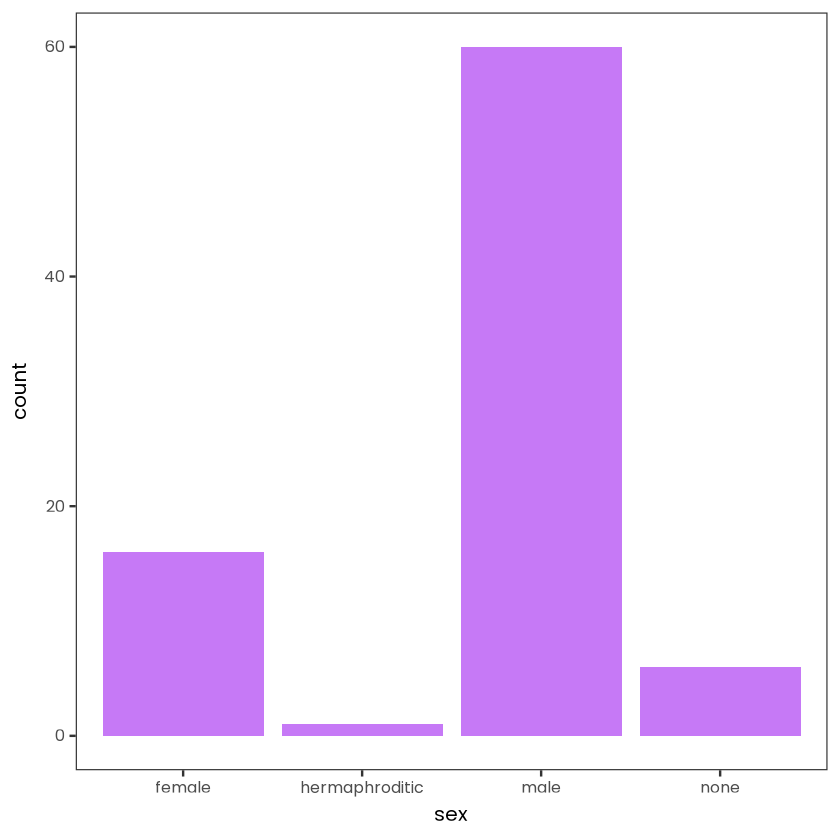

In [9]:
starwars %>%
  drop_na(sex) %>%  # শুধু sex কলামের NA গুলো বাদ দেওয়া
  ggplot(aes(sex)) +
  geom_bar(fill = "purple", alpha = 0.6)

**পার্থক্য:** drop_na() পুরো রো বাদ দেয় যদি কোথাও তথ্য না থাকে, আর drop_na(sex) শুধু লিঙ্গ কলামে তথ্য না থাকলে সেই চরিত্রটিকে বাদ দেয়।

### ৫. চার্ট ফ্লিপিং (Horizontal Bar Chart)
যদি এক্স-অক্ষের লেবেলগুলো অনেক বড় হয় বা অনেকগুলো ক্যাটাগরি থাকে, তবে চার্টটি ঘুরিয়ে দেওয়া (Flipping) ভালো।

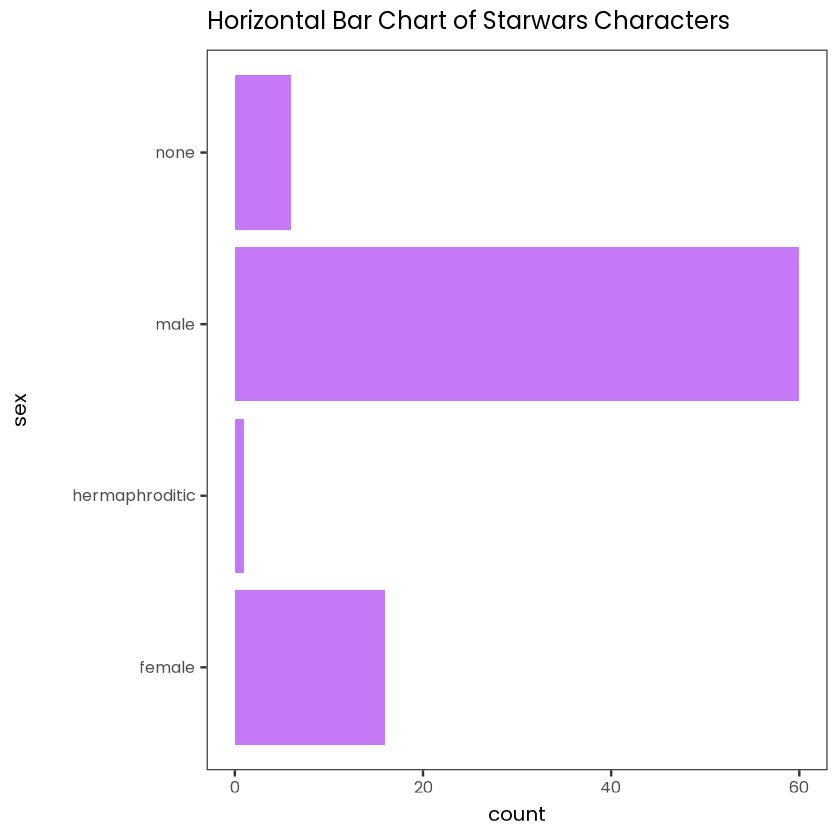

In [10]:
starwars %>%
  drop_na(sex) %>%
  ggplot(aes(sex)) +
  geom_bar(fill = "purple", alpha = 0.6) +
  coord_flip() + # চার্টটি ঘুরিয়ে দেওয়া
  labs(title = "Horizontal Bar Chart of Starwars Characters")

### ৬. বার সর্টিং (Sorting bars by Frequency)
বারগুলো এলোমেলো থাকার চেয়ে বড় থেকে ছোট (বা ছোট থেকে বড়) সাজানো থাকলে বুঝতে সুবিধা হয়।

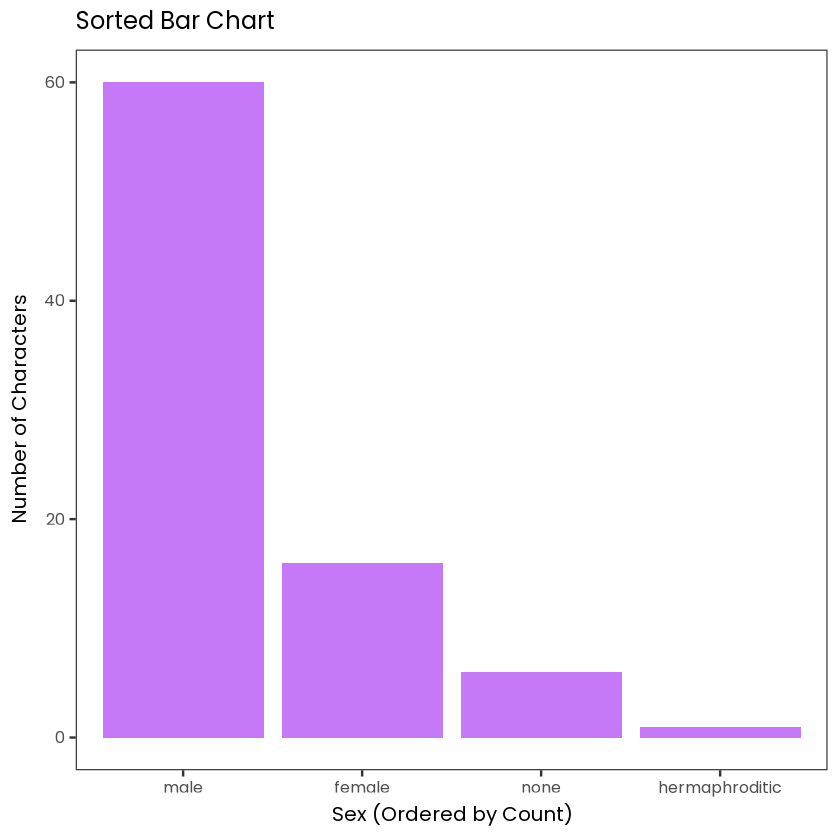

In [11]:
starwars %>%
  drop_na(sex) %>%
  ggplot(aes(fct_infreq(sex))) + # ফ্রিকোয়েন্সি অনুযায়ী সাজানো
  geom_bar(fill = "purple", alpha = 0.6) +
  labs(title = "Sorted Bar Chart",
       x = "Sex (Ordered by Count)",
       y = "Number of Characters")

**ব্যাখ্যা:** fct_infreq() ফাংশনটি forcats লাইব্রেরি থেকে আসে, যা বারগুলোকে তাদের সংখ্যা অনুযায়ী বড় থেকে ছোট ক্রমানুসারে সাজিয়ে দেয়।

#### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):
- geom_bar(): ক্যাটাগরির সংখ্যা গুনে বার তৈরি করে।
- fill ও alpha: বারের রঙ এবং স্বচ্ছতা নিয়ন্ত্রণ।
- drop_na(column): নির্দিষ্ট কলামের মিসিং ভ্যালু বাদ দেওয়া।
- coord_flip(): চার্টকে উলম্ব থেকে আনুভূমিক (Horizontal) করা।
- fct_infreq(): বারগুলোকে সংখ্যা অনুযায়ী সাজানো।

**অভিনন্দন!** আপনি এখন যে কোনো ক্যাটাগরিক্যাল ডেটা দিয়ে প্রফেশনাল বার চার্ট তৈরি করতে পারবেন।